In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("smartcart_customers.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

## data preprocessing

### 1. handle null values


In [3]:
# from sklearn.impute import SimpleImputer
# median = SimpleImputer(strategy="median")

df["Income"] = df["Income"].fillna(df["Income"].mean())

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2240 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

### 2. Feature engineering

In [4]:
# Age
df["Age"] = 2026-df["Year_Birth"]

In [5]:
# customer joining date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"] , dayfirst=True)
reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_date- df["Dt_Customer"]).dt.days #total dates

In [6]:
# spending
df["Total_spending"] = df["MntWines"] + df["MntFruits"]+ df["MntMeatProducts"]+ df["MntFishProducts"]+ df["MntSweetProducts"]+ df["MntGoldProds"] 

In [7]:
# total children 
df["Total_Children"] = df["Kidhome"] +df["Teenhome"]

In [8]:
# Education
df["Education"].value_counts()

df["Education"] = df["Education"].replace({
    "Basic" : "Undergraduate" , 
    "2n Cycle" :  "Undergraduate",
    "PhD" :  "Postgraduate",
    "Master" :  "Postgraduate",
    "Graduation" :  "Graduate",
})



In [9]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [10]:
# Marital status
df["Marital_Status"].value_counts()
df["living_with"] = df["Marital_Status"].replace({
    "Married" : "Partner" , "Together" :  "Partner",
    "Single" :  "Alone",
    "Divorced" :  "Alone",
    "Widow" :  "Alone",
    "Absurd" :  "Alone",
    "YOLO" :  "Alone",
})

In [11]:
df["living_with"].value_counts()

living_with
Partner    1444
Alone       796
Name: count, dtype: int64

### 3. drop columns

In [12]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_spending',
       'Total_Children', 'living_with'],
      dtype='object')

In [13]:
cols = ["ID" , "Year_Birth" ,"Marital_Status" , "Kidhome" ,"Teenhome" , "Dt_Customer"]
spending_cols =["MntWines" ,"MntFruits" ,"MntMeatProducts" , "MntFishProducts" ,"MntSweetProducts" , "MntGoldProds"]

cols_to_drop = cols + spending_cols 
df_cleaned = df.drop(cols_to_drop, axis = 1)  

In [14]:
df_cleaned.head()
df_cleaned.shape
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Education             2240 non-null   object 
 1   Income                2240 non-null   float64
 2   Recency               2240 non-null   int64  
 3   NumDealsPurchases     2240 non-null   int64  
 4   NumWebPurchases       2240 non-null   int64  
 5   NumCatalogPurchases   2240 non-null   int64  
 6   NumStorePurchases     2240 non-null   int64  
 7   NumWebVisitsMonth     2240 non-null   int64  
 8   Complain              2240 non-null   int64  
 9   Response              2240 non-null   int64  
 10  Age                   2240 non-null   int64  
 11  Customer_Tenure_Days  2240 non-null   int64  
 12  Total_spending        2240 non-null   int64  
 13  Total_Children        2240 non-null   int64  
 14  living_with           2240 non-null   object 
dtypes: float64(1), int64(

### 4. Outliers

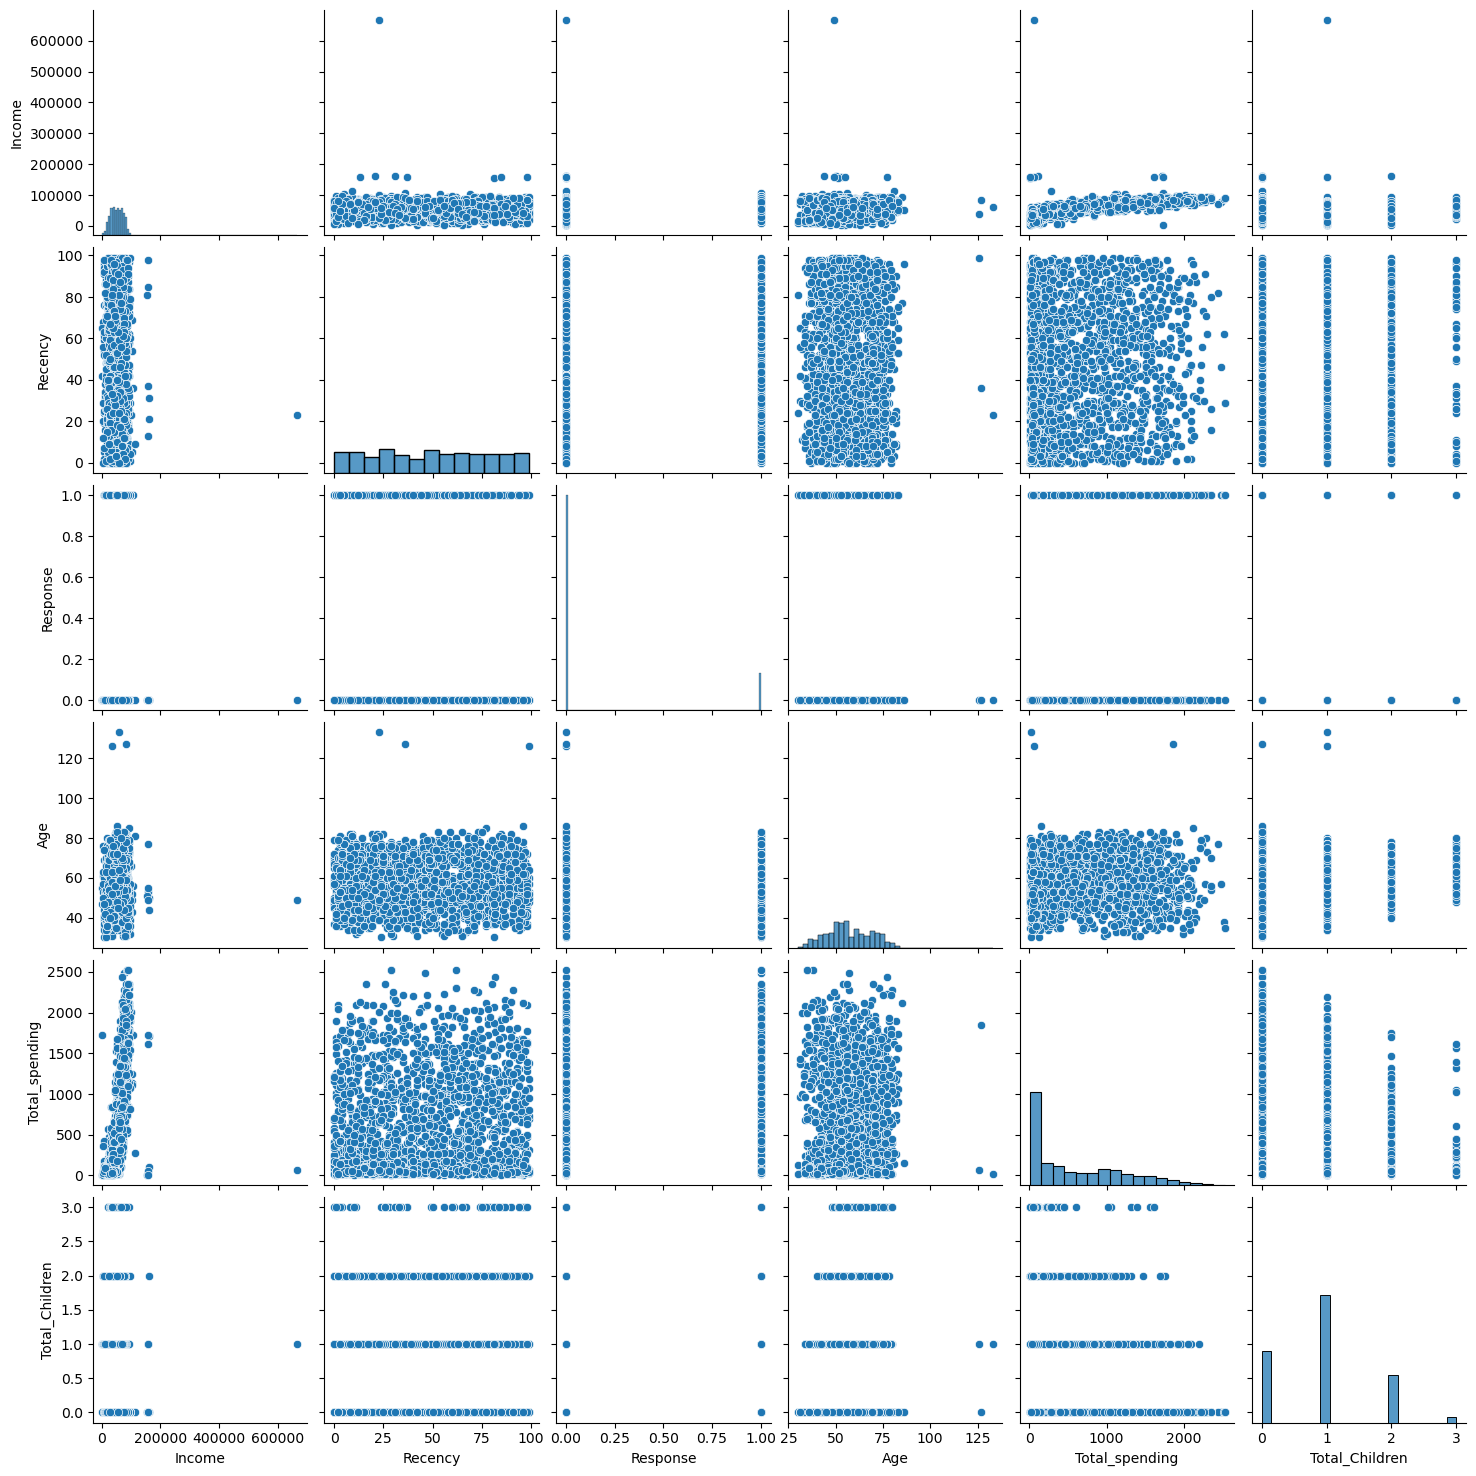

In [15]:
cols = ["Income","Recency","Response","Age","Total_spending","Total_Children"]

# relative plots of some features = pair plot
sns.pairplot(df_cleaned[cols])

In [16]:
# remove outliers
print("data size with outliers:" , len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["Age"]   < 900 )]
df_cleaned = df_cleaned[(df_cleaned["Income"]   < 600_000 )]

print("data size without outliers:" , len(df_cleaned))

data size with outliers: 2240
data size without outliers: 2239


### 4.2 Heatmaps

In [17]:
corr = df_cleaned.corr(numeric_only = True)
# corr

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

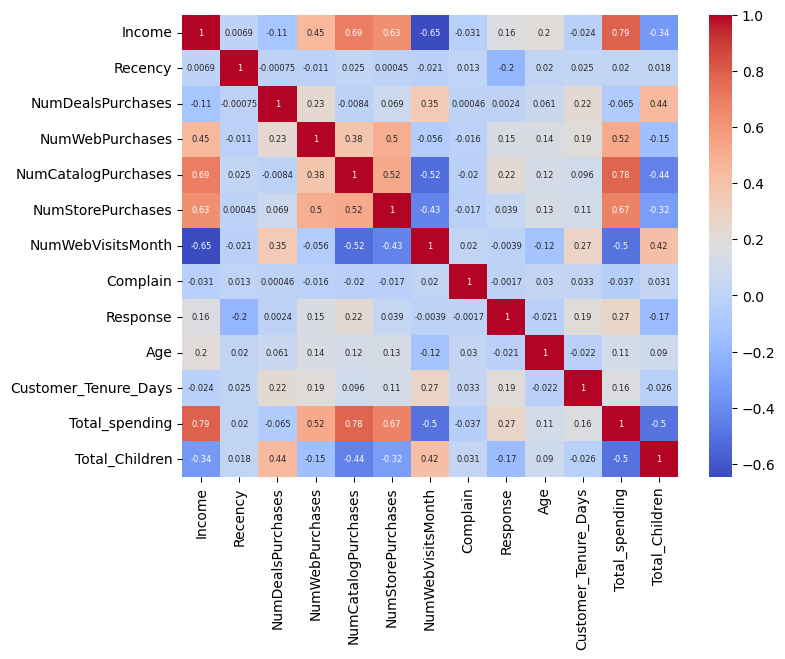

In [18]:
plt.figure(figsize = (8,6))

sns.heatmap( corr, annot=True , annot_kws = {"size" : 6} , cmap="coolwarm" )

plt.tight_layout

### 5. Encoding 

In [19]:
from sklearn.preprocessing import OneHotEncoder 

In [20]:
ohe = OneHotEncoder()
cat_cols = ["Education" , "living_with"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [21]:
enc_df = pd.DataFrame(enc_cols.toarray() , 
                      columns = ohe.get_feature_names_out(cat_cols) , 
                      index = df_cleaned.index)

enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,living_with_Alone,living_with_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [22]:
df_encoded = pd.concat([df_cleaned.drop(cat_cols , axis=1) ,enc_df] , axis = 1 )


In [23]:
df_encoded.shape

(2239, 18)

### 6. Scaling


In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
X = df_encoded

In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 7. Visualize 

In [27]:
X_scaled.shape  
#18 dimensions - cannot visualize -- pca

(2239, 18)

In [28]:
# 2d visualization 

# pca 
from sklearn.decomposition import PCA 
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

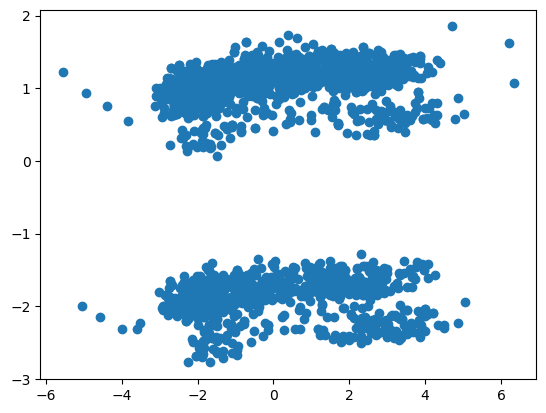

In [29]:
# plot

plt.scatter(X_pca[: , 0] , X_pca[:,1] , )

In [30]:
pca.explained_variance_ratio_ 
#omly 33% approx variance in absorbed -- not good -- dimension -- increase 

array([0.23151952, 0.11381766])

In [31]:
# 3rd visualizarion 

pca = PCA(n_components = 3)
X_pca = pca.fit_transform(X_scaled)

pca.explained_variance_ratio_ 
#approx - 43% -- better

array([0.23151952, 0.11381766, 0.10376357])

Text(0.5, 0.92, '3D projection ')

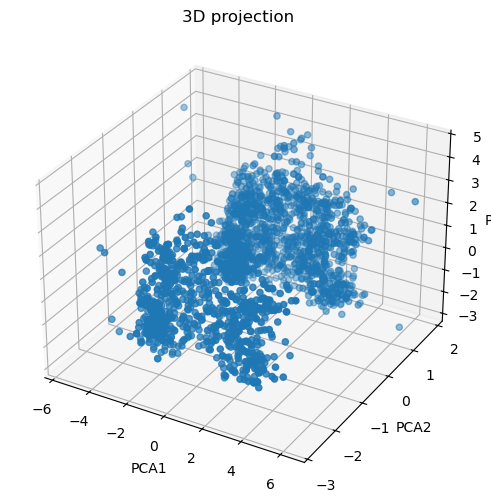

In [32]:
# plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[: , 0] , X_pca[:,1] , X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D projection ")

## Analyse k  value

### 1. Elbow method

In [33]:
from sklearn.cluster import KMeans 
from kneed import KneeLocator 

wcss = [] 
for k in range (1 , 11):
    kmeans = KMeans(n_clusters = k , random_state=42 )
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [34]:

knee = KneeLocator(range(1,11) , wcss , curve = "convex" , direction = "decreasing")
optimal_k = knee.elbow

In [35]:
print("Best K : " , optimal_k)

Best K :  4


Text(0, 0.5, 'WCSS')

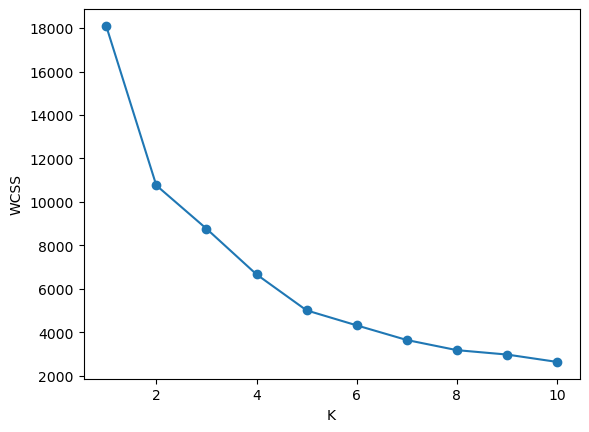

In [36]:
# plot wcss
plt.plot(range(1,11) , wcss , marker="o" )
plt.xlabel("K")
plt.ylabel("WCSS")

### 2. Silhoutte Score 

Text(0, 0.5, 'silhouette_score')

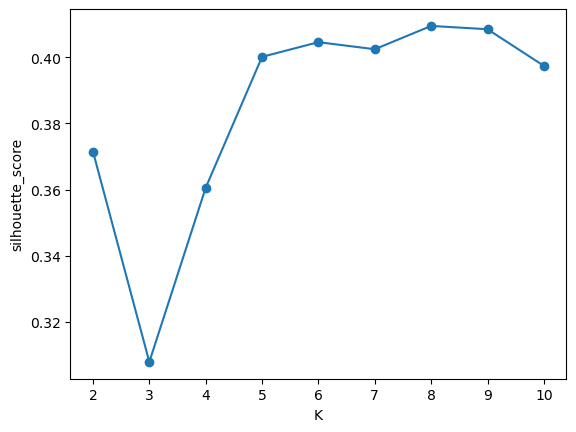

In [37]:
from sklearn.metrics import silhouette_score

scores = [] 
for k in range (2 , 11):
    kmeans = KMeans(n_clusters = k , random_state=42 )
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca , labels)
    scores.append(score) 


# plot
plt.plot(range(2,11) , scores , marker="o" )
plt.xlabel("K")
plt.ylabel("silhouette_score")

Text(0, 0.5, 'Scores')

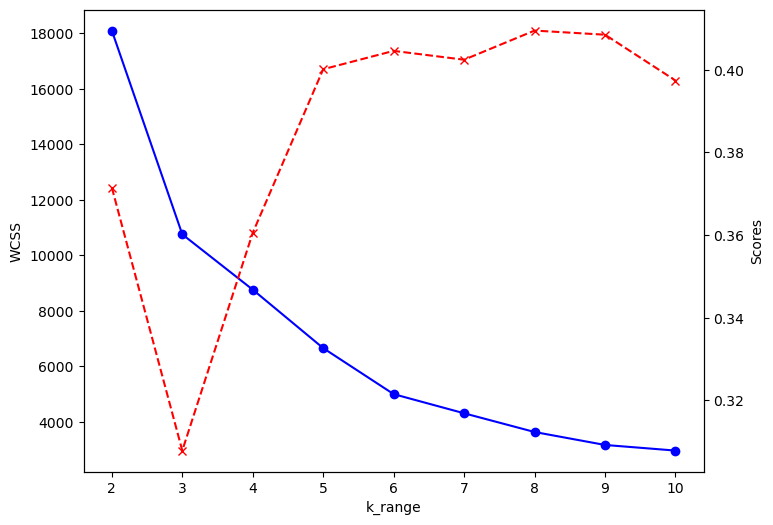

In [38]:
# combined plot 
k_range = range(2,11) 
fig , ax1 = plt.subplots(figsize=(8,6)) 

ax1.plot(k_range , wcss[:len(k_range)] , marker="o" , color="blue" )
ax1.set_xlabel("k_range")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx() #twin of ax1  from x axis 

ax2.plot(k_range , scores[:len(k_range)] , marker="x" , color="red" , linestyle="--" )
ax2.set_ylabel("Scores")


In [39]:
# we can clearly see -- 4 is the optimal k value 

## Clustering

In [40]:
# Kmeans 
kmeans = KMeans(n_clusters = 4 , random_state = 42) 
labels_kmeans = kmeans.fit_predict(X_pca) 


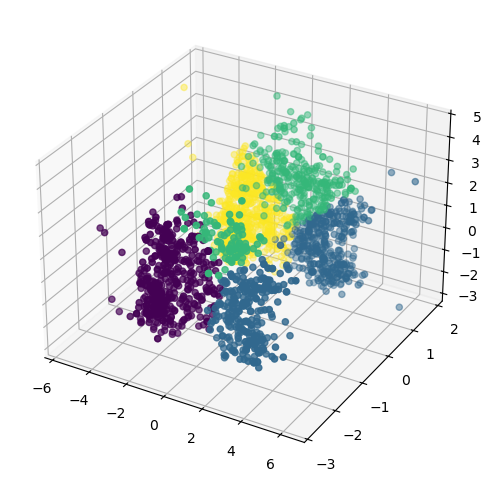

In [41]:
# plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[: , 0] , X_pca[:,1] , X_pca[:,2] , c = labels_kmeans )

In [42]:
# Agglomerative clustering 

from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering(n_clusters = 4 , linkage= "ward")
labels_agg = agg_clf.fit_predict(X_pca)

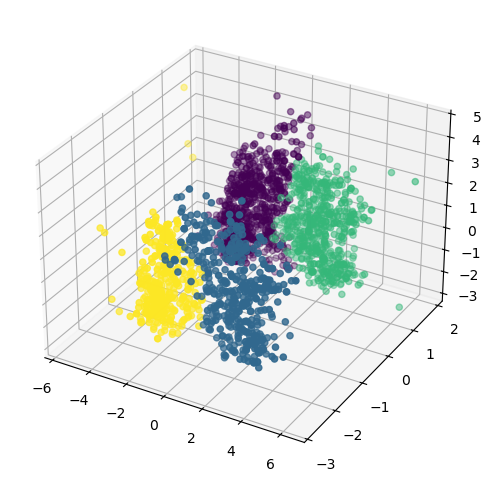

In [43]:
# plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[: , 0] , X_pca[:,1] , X_pca[:,2] , c = labels_agg )

In [44]:
# better separated -- better clusteration 

## Characterization of clusters

In [45]:
X["cluster"] = labels_agg #new column label in cleaned data have kinda predicted val 


In [46]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,living_with_Alone,living_with_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,1
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,3
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,2
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

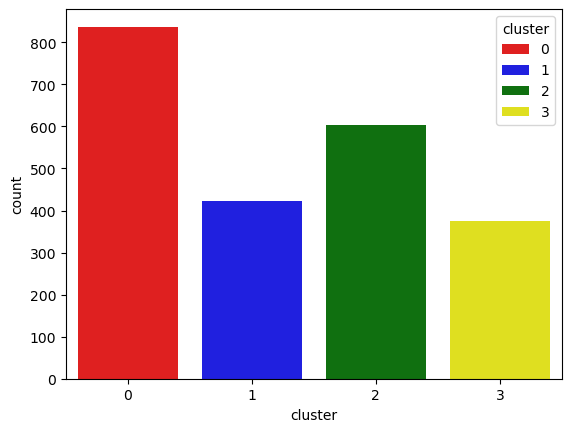

In [47]:
# number of customer in each clusters

pal = ["red" , "blue" , "green" , "yellow"] #colour palatte

sns.countplot(x = X["cluster"] , palette = pal , hue = X["cluster"] )

### Analyze

<Axes: xlabel='Total_spending', ylabel='Income'>

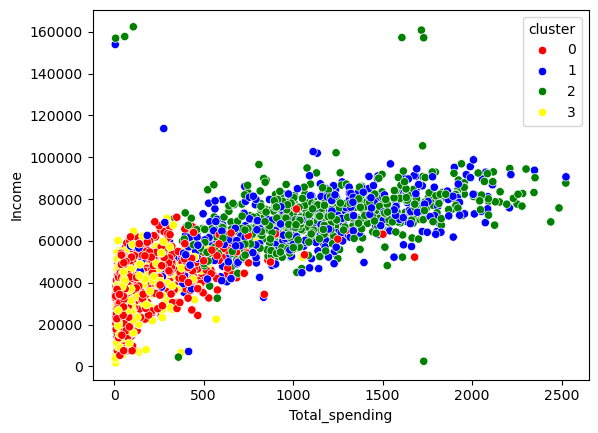

In [48]:
# Income and Spending patterns

sns.scatterplot( x =X["Total_spending"],  y = X["Income"] ,
                 hue = X["cluster"] , palette= pal)

# cluster = 0 - red == low - moderate income , low - moderate spending
# cluster = 1 - blue == high income , high spending
# cluster = 2 - green == low  income , low  spending
# cluster = 3 - yellow == moderate-high  income , high  spending


In [49]:
# cluster summary 

cluster_summary = X.groupby("cluster").mean()

print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        38041.934903  48.868578           2.605735         2.930705   
1        67286.127078  49.300236           2.245863         5.666667   
2        71385.054735  49.212272           2.013267         5.708126   
3        34624.621701  49.335106           2.284574         2.273936   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.839904           3.838710           6.457587  0.008363   
1                   4.513002           7.992908           4.184397  0.004728   
2                   5.167496           8.565506           3.674959  0.009950   
3                   0.622340           3.212766           6.680851  0.015957   

         Response        Age  Customer_Tenure_Days  Total_spending  \
cluster         